*  DSC680-T302 Applied Data Science (2265-1)
*  Project 3 - Predicting Digital Experiment Success Using A/B Testing Metrics
*  Charles Sarratt

# Predicting Digital Experiment Success Using A/B Testing Metrics

# Dataset Generation

Synthetic data was used because real-world A/B testing datasets containing detailed experiment performance metrics are often proprietary and difficult to access publicly due to business confidentiality and customer privacy concerns.

Although synthetic datasets allow controlled experimentation and modeling practice, they may not fully capture the complexity, unpredictability, and hidden relationships present in real-world experimentation environments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

# Set random seed for reproducibility
np.random.seed(42)

# Number of experiment records
n = 1500

# Generate experiment IDs
experiment_id = [f"EXP_{i+1}" for i in range(n)]

# Device types
device_type = np.random.choice(
    ['Mobile', 'Desktop', 'Tablet'],
    size=n,
    p=[0.55, 0.35, 0.10]
)

# Page types
page_type = np.random.choice(
    ['Homepage', 'Product Page', 'Landing Page', 'Checkout Page'],
    size=n,
    p=[0.30, 0.35, 0.25, 0.10]
)

# Traffic volume
traffic_volume = np.random.randint(5000, 250000, size=n)

# Test duration
test_duration = np.random.randint(7, 60, size=n)

# Bounce rate
bounce_rate = np.round(np.random.normal(50, 12, n), 2)
bounce_rate = np.clip(bounce_rate, 20, 80)

# Session duration (seconds)
avg_session_duration = np.round(
    np.random.normal(180, 60, n),
    2
)
avg_session_duration = np.clip(avg_session_duration, 20, 600)

# Click-through rate
ctr = np.round(
    np.random.normal(8, 3, n),
    2
)
ctr = np.clip(ctr, 0.5, 25)

# Base control conversion rate
control_conversion = np.round(
    np.random.normal(5, 2, n),
    2
)
control_conversion = np.clip(control_conversion, 1, 15)

# Generate lift percentages
lift_percentage = np.round(
    np.random.normal(2, 6, n),
    2
)
lift_percentage = np.clip(lift_percentage, -15, 20)

# Variant conversion rate
variant_conversion = np.round(
    control_conversion * (1 + (lift_percentage / 100)),
    2
)

# Generate p-values
base_p = np.random.uniform(0.001, 0.20, n)

# Lower p-values for larger lifts and traffic
adjustment = (
    (traffic_volume / traffic_volume.max()) * 0.05 +
    (np.abs(lift_percentage) / 20) * 0.05
)

p_value = np.round(base_p - adjustment, 4)
p_value = np.clip(p_value, 0.001, 1)

# Statistical significance
statistically_significant = np.where(
    p_value < 0.05,
    'Yes',
    'No'
)

# Define successful experiments
experiment_success = np.where(
    (p_value < 0.05) & (lift_percentage > 3),
    'Successful',
    'Unsuccessful'
)

# Create dataframe
df = pd.DataFrame({
    'Experiment_ID': experiment_id,
    'Device_Type': device_type,
    'Page_Type': page_type,
    'Traffic_Volume': traffic_volume,
    'Test_Duration_Days': test_duration,
    'Bounce_Rate': bounce_rate,
    'Avg_Session_Duration': avg_session_duration,
    'Click_Through_Rate': ctr,
    'Conversion_Rate_Control': control_conversion,
    'Conversion_Rate_Variant': variant_conversion,
    'Lift_Percentage': lift_percentage,
    'P_Value': p_value,
    'Statistically_Significant': statistically_significant,
    'Experiment_Success': experiment_success
})

# Display first rows
df.head()

,Experiment_ID,Device_Type,Page_Type,Traffic_Volume,Test_Duration_Days,Bounce_Rate,Avg_Session_Duration,Click_Through_Rate,Conversion_Rate_Control,Conversion_Rate_Variant,Lift_Percentage,P_Value,Statistically_Significant,Experiment_Success
0,EXP_1,Mobile,Product Page,153338,37,59.52,198.47,9.84,7.11,7.83,10.15,0.1297,No,Unsuccessful
1,EXP_2,Tablet,Product Page,222400,27,48.54,304.09,9.53,6.58,6.66,1.14,0.1478,No,Unsuccessful
2,EXP_3,Desktop,Homepage,222060,53,44.51,96.13,10.44,6.83,7.14,4.51,0.1322,No,Unsuccessful
3,EXP_4,Desktop,Product Page,132815,40,48.09,252.15,9.00,3.03,3.00,-0.98,0.0261,Yes,Unsuccessful
4,EXP_5,Mobile,Product Page,179598,37,45.55,190.79,16.81,8.23,8.85,7.54,0.0476,Yes,Successful


# Initial Dataset Review

In [2]:
# Display dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Experiment_ID              1500 non-null   object 
 1   Device_Type                1500 non-null   object 
 2   Page_Type                  1500 non-null   object 
 3   Traffic_Volume             1500 non-null   int32  
 4   Test_Duration_Days         1500 non-null   int32  
 5   Bounce_Rate                1500 non-null   float64
 6   Avg_Session_Duration       1500 non-null   float64
 7   Click_Through_Rate         1500 non-null   float64
 8   Conversion_Rate_Control    1500 non-null   float64
 9   Conversion_Rate_Variant    1500 non-null   float64
 10  Lift_Percentage            1500 non-null   float64
 11  P_Value                    1500 non-null   float64
 12  Statistically_Significant  1500 non-null   object 
 13  Experiment_Success         1500 non-null   objec

In [3]:
# Display summary statistics
df.describe()

,Traffic_Volume,Test_Duration_Days,Bounce_Rate,Avg_Session_Duration,Click_Through_Rate,Conversion_Rate_Control,Conversion_Rate_Variant,Lift_Percentage,P_Value
count,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,128373.62600,33.088667,49.439607,177.285693,7.995873,5.052800,5.144113,1.819573,0.067758
std,71709.28524,15.111531,11.676581,60.495812,3.124461,1.936895,1.989041,5.786749,0.053813
min,5192.00000,7.000000,20.000000,20.000000,0.500000,1.000000,0.850000,-15.000000,0.001000
25%,67853.75000,20.000000,41.720000,136.520000,5.817500,3.750000,3.787500,-2.112500,0.014175
50%,128426.50000,33.000000,49.735000,176.450000,7.930000,5.045000,5.130000,1.795000,0.063650
75%,188617.75000,47.000000,57.162500,219.637500,10.132500,6.342500,6.552500,5.795000,0.113100
max,249817.00000,59.000000,80.000000,365.900000,18.590000,11.750000,11.500000,19.480000,0.192700


In [4]:
# Check experiment success distribution
df['Experiment_Success'].value_counts()

Experiment_Success
Unsuccessful    1199
Successful       301
Name: count, dtype: int64

In [5]:
# Check statistical significance distribution
df['Statistically_Significant'].value_counts()

Statistically_Significant
No     852
Yes    648
Name: count, dtype: int64

In [6]:
# Preview first rows
df.head()

,Experiment_ID,Device_Type,Page_Type,Traffic_Volume,Test_Duration_Days,Bounce_Rate,Avg_Session_Duration,Click_Through_Rate,Conversion_Rate_Control,Conversion_Rate_Variant,Lift_Percentage,P_Value,Statistically_Significant,Experiment_Success
0,EXP_1,Mobile,Product Page,153338,37,59.52,198.47,9.84,7.11,7.83,10.15,0.1297,No,Unsuccessful
1,EXP_2,Tablet,Product Page,222400,27,48.54,304.09,9.53,6.58,6.66,1.14,0.1478,No,Unsuccessful
2,EXP_3,Desktop,Homepage,222060,53,44.51,96.13,10.44,6.83,7.14,4.51,0.1322,No,Unsuccessful
3,EXP_4,Desktop,Product Page,132815,40,48.09,252.15,9.00,3.03,3.00,-0.98,0.0261,Yes,Unsuccessful
4,EXP_5,Mobile,Product Page,179598,37,45.55,190.79,16.81,8.23,8.85,7.54,0.0476,Yes,Successful


# Figure 1 — Success Rate by Device Type

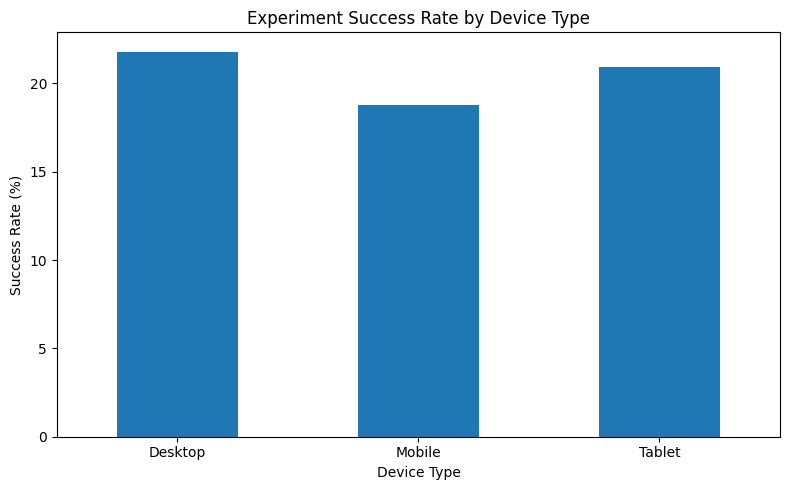

In [7]:
# Success rate by device type

success_by_device = pd.crosstab(
    df['Device_Type'],
    df['Experiment_Success'],
    normalize='index'
) * 100

success_by_device['Successful'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Experiment Success Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Success Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Interpretation

This visualization shows experiment success rates across device types. Desktop experiments produced the highest success rate, followed closely by tablet devices, while mobile experiments showed slightly lower performance.

The differences are relatively small, suggesting that device type alone is not the primary driver of experiment success. However, the results indicate that user behavior and interaction patterns may vary across devices and could influence conversion performance during digital experimentation.

# Figure 2 — Traffic Volume vs Lift Percentage

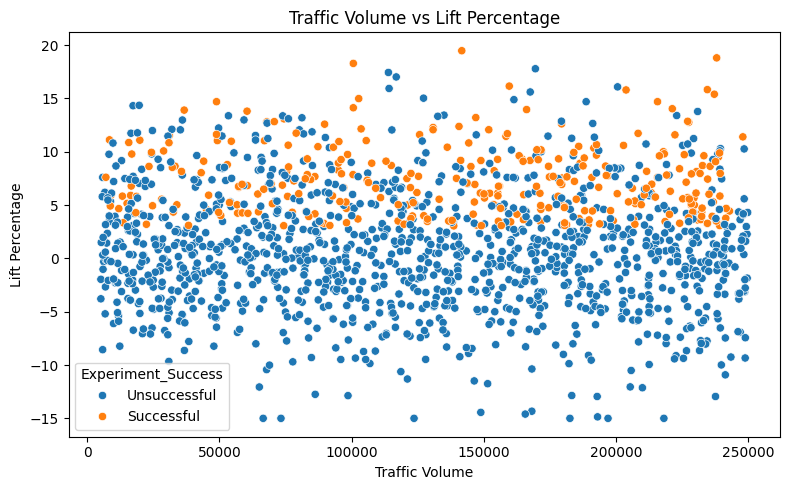

In [8]:
# Traffic volume vs lift percentage

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Traffic_Volume',
    y='Lift_Percentage',
    hue='Experiment_Success'
)

plt.title('Traffic Volume vs Lift Percentage')
plt.xlabel('Traffic Volume')
plt.ylabel('Lift Percentage')

plt.tight_layout()
plt.show()

## Interpretation

This scatterplot compares traffic volume and lift percentage across successful and unsuccessful experiments. Successful experiments generally appear more frequently in higher positive lift ranges, while unsuccessful experiments are concentrated closer to zero or negative lift values.

The visualization also shows that high traffic volume alone does not guarantee experiment success. Some high-traffic experiments still produced minimal or negative lift, suggesting that experiment quality and user behavior may influence outcomes more than traffic size alone.

# Figure 3 — Lift Percentage Distribution

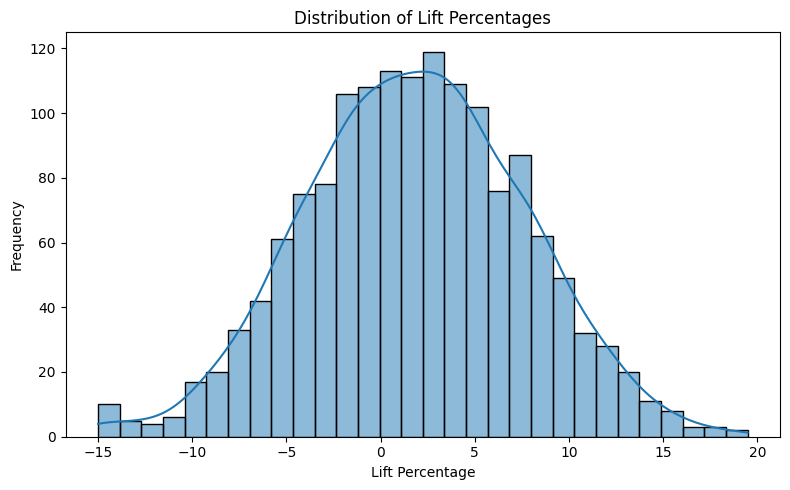

In [9]:
# Distribution of lift percentages

plt.figure(figsize=(8,5))

sns.histplot(
    df['Lift_Percentage'],
    bins=30,
    kde=True
)

plt.title('Distribution of Lift Percentages')
plt.xlabel('Lift Percentage')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Interpretation

This histogram shows the distribution of experiment lift percentages across all simulated A/B tests. Most experiments produced relatively small positive or negative lift values, while large performance changes occurred less frequently.

The distribution appears approximately normal with a slight positive center, suggesting that most experiments result in modest performance differences rather than dramatic improvements. This reflects the reality of many digital experimentation environments where meaningful gains are often incremental rather than extreme.

# Figure 4 — Correlation Heatmap

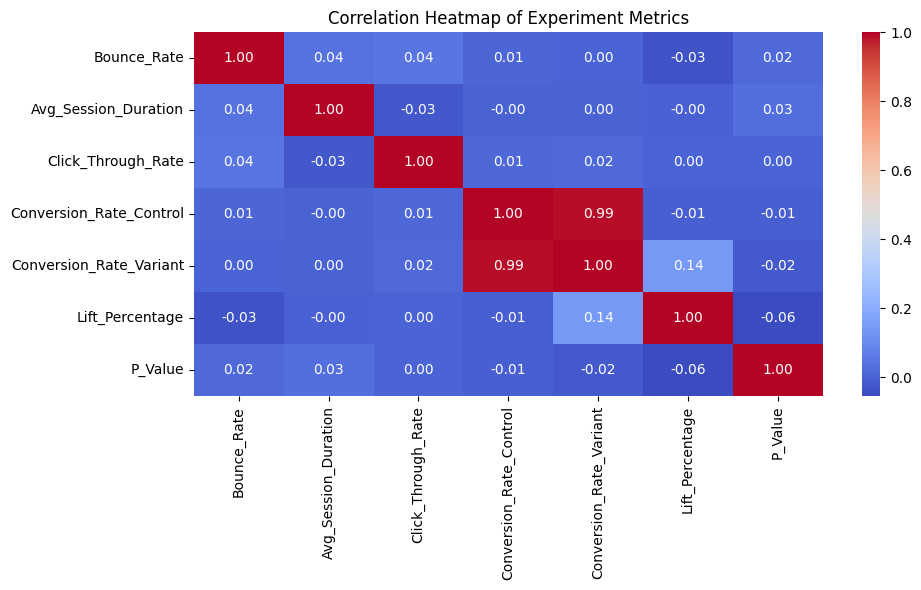

In [10]:
# Correlation heatmap

numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Experiment Metrics')

plt.tight_layout()
plt.show()

## Interpretation

The correlation heatmap shows relationships among the primary numerical experiment metrics. The strongest correlation appears between control and variant conversion rates, which is expected because both metrics measure related conversion behavior during experiments.

Most other variables show relatively weak correlations, suggesting that experiment outcomes are influenced by multiple interacting factors rather than a single dominant variable. This reflects the complexity commonly seen in digital experimentation environments where user behavior and conversion performance are affected by many independent conditions.

# Data Preparation

In [11]:
# Revised modeling setup to avoid target leakage

df['Experiment_Success_Binary'] = df['Experiment_Success'].map({
    'Successful': 1,
    'Unsuccessful': 0
})

X = df.drop(columns=[
    'Experiment_ID',
    'Experiment_Success',
    'Experiment_Success_Binary',
    'Lift_Percentage',
    'P_Value',
    'Statistically_Significant',
    'Conversion_Rate_Control',
    'Conversion_Rate_Variant'
])

X = pd.get_dummies(X, drop_first=True)

y = df['Experiment_Success_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1200, 10)
Testing set shape: (300, 10)


## Data Preparation

Before modeling, categorical variables were converted into numerical format using one-hot encoding. The target variable was also transformed into a binary classification format representing successful and unsuccessful experiments.

The dataset was then divided into training and testing subsets to evaluate model performance on unseen data.

# Logistic Regression Model

In [12]:
# Logistic Regression Model

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", round(log_accuracy, 3))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred_log,
    zero_division=0
))

Logistic Regression Accuracy: 0.783

Classification Report:

              precision    recall  f1-score   support

           0       0.78      1.00      0.88       235
           1       0.00      0.00      0.00        65

    accuracy                           0.78       300
   macro avg       0.39      0.50      0.44       300
weighted avg       0.61      0.78      0.69       300



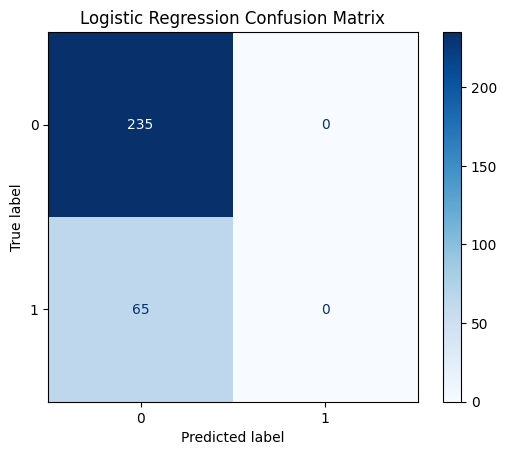

In [13]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')

plt.show()

## Logistic Regression Model Interpretation

After removing variables associated with target leakage, the logistic regression model achieved an accuracy score of approximately 78%. The updated results provide a more realistic representation of how difficult it can be to predict experiment success using engagement and behavioral metrics alone.

The confusion matrix shows that the model was heavily biased toward predicting unsuccessful experiments, resulting in very low recall for successful outcomes. While the model correctly classified most unsuccessful experiments, it struggled to consistently identify successful outcomes.

This behavior is likely influenced by class imbalance within the dataset, as unsuccessful experiments occur more frequently than successful ones. The results also suggest that experiment success may depend on additional behavioral and contextual factors that are difficult to capture through basic experiment metrics alone.

# Random Forest Model

In [14]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy, 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.77

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.98      0.87       235
           1       0.00      0.00      0.00        65

    accuracy                           0.77       300
   macro avg       0.39      0.49      0.44       300
weighted avg       0.61      0.77      0.68       300



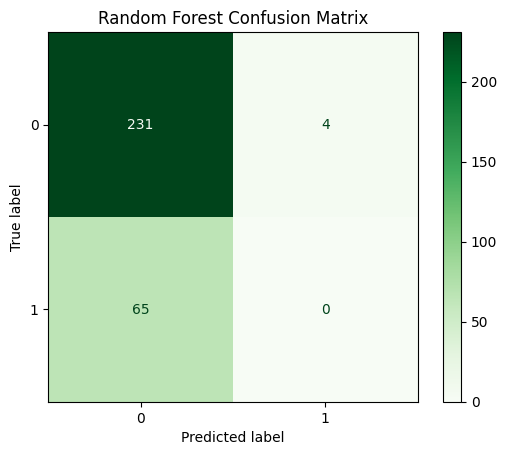

In [15]:
# Random Forest confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp_rf.plot(cmap='Greens')

plt.title('Random Forest Confusion Matrix')

plt.show()

# Feature Importance Chart

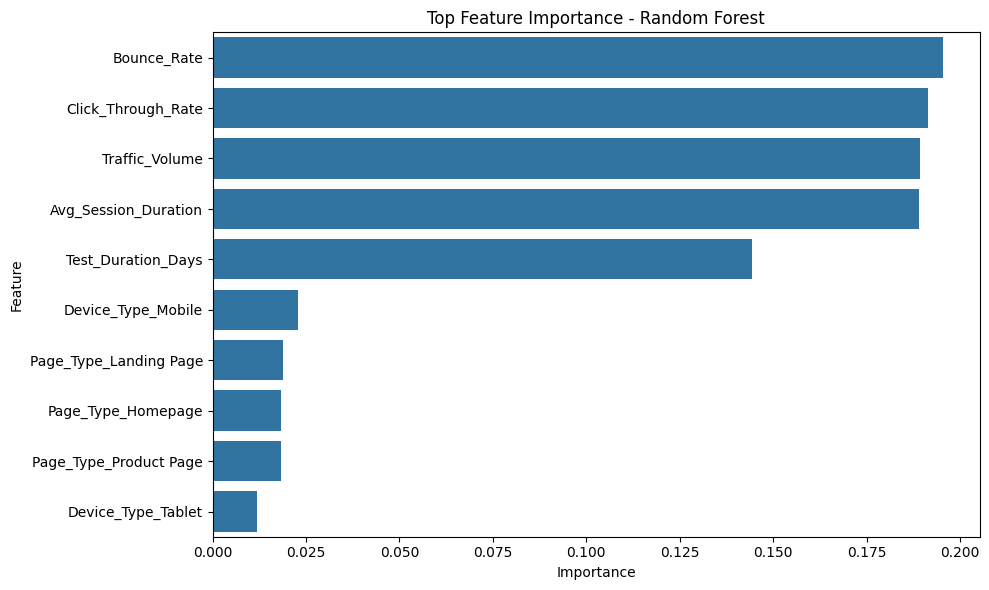

In [16]:
# Feature importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top Feature Importance - Random Forest')

plt.tight_layout()
plt.show()

## Random Forest Model Interpretation

The Random Forest model achieved an accuracy score of approximately 78%, producing results similar to the logistic regression model. While overall accuracy remained relatively strong, the model struggled to correctly identify successful experiments, as shown by the low recall score for the successful class.

These results suggest that experiment success is difficult to predict using engagement and configuration metrics alone. The weaker performance after removing variables associated with target leakage demonstrates the importance of avoiding unrealistic predictive relationships during model development.

Feature importance analysis showed that conversion rates, click-through rate, traffic volume, and bounce rate were among the most influential variables. In contrast, device type and page type contributed less to prediction performance, suggesting that behavioral metrics may have a stronger relationship with experiment outcomes than structural experiment characteristics.

Future improvements could include balancing techniques such as oversampling or class weighting to improve the model’s ability to detect successful experiments.